# **Course Task: Tokenization Efficiency Benchmark**

Author: Bartosz Hanc

This report details an experiment to analyze and compare the performance of
three distinct tokenization strategies. We implemented, trained, and evaluated
three language models using identical architectures and training data. The only
variable differentiating these experiments was the tokenizer.

## Dataset

The training data consisted of the first 10K documents from the "plwiki" dataset
downloaded from Speakleash. The script used to download and prepare the data is
provided in `download.py` file.

In [1]:
import os

text_train = open("train.txt").read()
text_valid = open("valid.txt").read()

print(f"Train. size: {os.path.getsize("train.txt") / (1024 * 1024):.2f} MB")
print(f"Valid. size: {os.path.getsize("valid.txt") / (1024 * 1024):.2f} MB")

Train. size: 49.25 MB
Valid. size: 5.47 MB


## Tokenizers

The experiment used three tokenizers, all configured to use a consistent
vocabulary size derived from the pre-trained GPT-2 model. We used the following
tokenizers.

In [2]:
from abc import abstractmethod
from typing import Protocol


class Tokenizer(Protocol):
    vocab_size: int

    @abstractmethod
    def encode(self, text: str) -> list[int]: ...
    @abstractmethod
    def decode(self, toks: list[int]) -> str: ...

1. **Pre-trained (GPT-2)**: A standard, general-purpose Byte-Pair Encoding (BPE)
   tokenizer pre-trained on web text.

In [3]:
from transformers import AutoTokenizer

hf_tokenizer = AutoTokenizer.from_pretrained("openai-community/gpt2")
VOCAB_SIZE = hf_tokenizer.vocab_size
print(f"{VOCAB_SIZE=}")

VOCAB_SIZE=50257


2. **Whitespace-based**: A custom-implemented, fixed-vocabulary tokenizer with
   special token for unknown words, trained on train split of our dataset (using
   only top `VOCAB_SIZE - 1` most frequent words).

In [4]:
import regex
from collections import Counter


class WhitespaceTokenizer(Tokenizer):
    def __init__(self, vocab_size: int, unk_token: str = "<UNK>"):
        self.vocab_size = vocab_size

        self.unk_token = unk_token
        self.num_special_tokens = 1

        self.vocab: dict[str, int] = {}
        self.reverse_vocab: dict[int, str] = {}

    def _pre_tokenize(self, text: str) -> list[str]:
        pattern = r"[\p{L}\p{N}]+|[^\s\p{L}\p{N}]"
        return regex.findall(pattern, text.lower())

    def train(self, text: str) -> None:
        toks = self._pre_tokenize(text)
        most_common = Counter(toks).most_common(self.vocab_size - self.num_special_tokens)

        self.vocab = {tok: idx + self.num_special_tokens for idx, (tok, _) in enumerate(most_common)}
        self.vocab |= {self.unk_token: 0}
        self.reverse_vocab = {idx: tok for tok, idx in self.vocab.items()}

    def encode(self, text: str) -> list[int]:
        toks = self._pre_tokenize(text)
        return [self.vocab.get(tok, self.vocab[self.unk_token]) for tok in toks]

    def decode(self, toks: list[int]) -> str:
        return " ".join(self.reverse_vocab[tok] for tok in toks)


whitespace_tokenizer = WhitespaceTokenizer(vocab_size=VOCAB_SIZE)
whitespace_tokenizer.train(text_train)

3. **SentencePiece**: A Unigram subword tokenizer trained from scratch on our
   specific training corpus.

In [ ]:
import sentencepiece as spm

spm.SentencePieceTrainer.train(f"--input=train.txt --model_prefix=m --vocab_size={VOCAB_SIZE}")  # type: ignore
sp_tokenizer = spm.SentencePieceProcessor()
sp_tokenizer.load("m.model");  # type: ignore

## Model Training

To ensure a fair comparison, three identical Transformer-based language models
were trained. We utilized the model architecture from the previous lab along
with the training and evaluation code, both of which are provided in the
`gpt.py` file.

In [6]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device.upper()}")

Using device: CUDA


The model architecture and training hyperparameters are specified in the cell
below. We trained all models for 5000 epochs on a NVIDIA GTX 1660 Super GPU with
6GB of VRAM. The parameter count of the used language model was ~50M. The total
training time (for all three models) was ~36 hours.

In [ ]:
from gpt import GPTLanguageModel, train


batch_size = 64
block_size = 256
log_period = 500
num_epochs = 5000
num_layers = 6
num_evals = 200
num_heads = 6
dim_model = 384
dropout_p = 0.2

for tokenizer in [hf_tokenizer, whitespace_tokenizer, sp_tokenizer]:
    train(
        model=GPTLanguageModel(
            vocab_size=VOCAB_SIZE,
            block_size=block_size,
            num_layers=num_layers,
            dim_model=dim_model,
            num_heads=num_heads,
            dropout_p=dropout_p,
        ),
        text_train=text_train,
        text_valid=text_valid,
        tokenizer=tokenizer,
        batch_size=batch_size,
        block_size=block_size,
        num_epochs=num_epochs,
        log_period=log_period,
        num_evals=num_evals,
        device=device,
        name=type(tokenizer).__name__,
    )

## Evaluation Metrics

While cross-entropy loss is the standard optimization objective, it is not
directly comparable across models with different vocabularies. A "token" for the
Whitespace model (a full word) is fundamentally different from a "token" for the
BPE model (a subword).

In [7]:
import matplotlib.pyplot as plt


def plot_loss(path: str, title: str = ""):
    loss_hist = torch.load(f"{path}/chk_4999.pt")["loss"]
    train_loss_epochs = sorted(loss_hist["train"].keys())
    train_loss_values = [loss_hist["train"][e] for e in train_loss_epochs]
    valid_loss_epochs = sorted(loss_hist["valid"].keys())
    valid_loss_values = [loss_hist["valid"][e] for e in valid_loss_epochs]

    plt.plot(train_loss_epochs, train_loss_values, label=f"{title} | Training Loss", alpha=0.6)
    plt.plot(valid_loss_epochs, valid_loss_values, label=f"{title} | Validation Loss", marker=".", ls="--")
    plt.xlabel("Epoch")
    plt.ylabel("Cross-Entropy Loss")
    plt.legend()

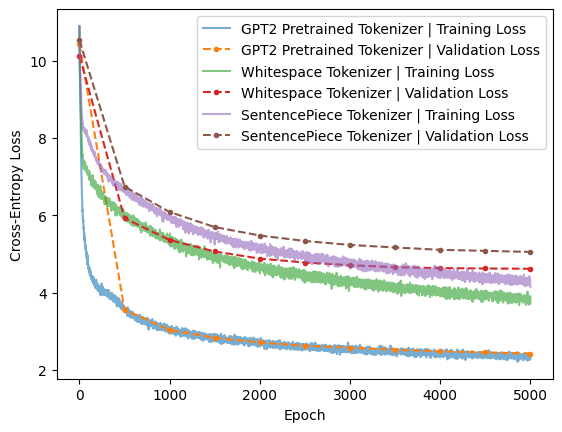

In [8]:
plot_loss("checkpoints/GPT2TokenizerFast", title="GPT2 Pretrained Tokenizer")
plot_loss("checkpoints/WhitespaceTokenizer", title="Whitespace Tokenizer")
plot_loss("checkpoints/SentencePieceProcessor", title="SentencePiece Tokenizer")

### Perplexity

To provide a fair comparison, we normalize the loss by units that are consistent
across all models: words and characters. Namely given the average cross-entropy
loss computed during training, we first multiply it by the number of tokens
produced by the given tokenizer to obtain the total loss and afterwards divide
the total loss by the number of words or characters

$$
    \text{PPL}_\text{word} = \exp \left( \frac{\text{Avg. NLL} \times \text{Tot. tokens}}{\text{Tot. words}} \right)
$$
$$
    \text{PPL}_\text{char} = \exp \left( \frac{\text{Avg. NLL} \times \text{Tot. tokens}}{\text{Tot. chars.}} \right)
$$

#### Word-level perplexity

Words were counted using the same regex as the one used in the whitespace tokenizer.

        GPT2TokenizerFast Final Word-level PPL (Valid. set) 1516.77
      WhitespaceTokenizer Final Word-level PPL (Valid. set) 349.29
   SentencePieceProcessor Final Word-level PPL (Valid. set) 156.87


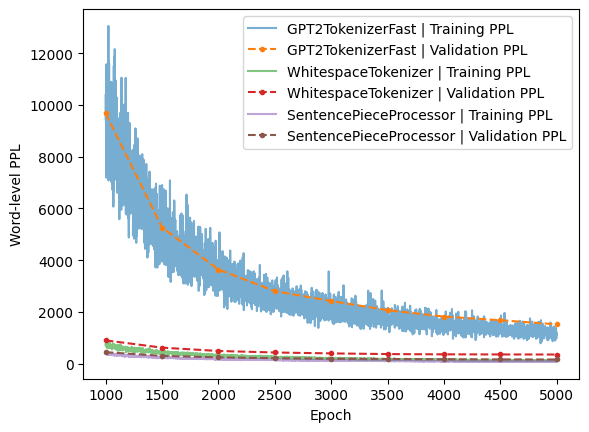

In [43]:
import numpy as np

train_tot_words = len(whitespace_tokenizer.encode(text_train))
valid_tot_words = len(whitespace_tokenizer.encode(text_valid))

for name, tokenizer in zip(
    ("GPT2TokenizerFast", "WhitespaceTokenizer", "SentencePieceProcessor"),
    (hf_tokenizer, sp_tokenizer, whitespace_tokenizer),
):
    loss_hist = torch.load(f"checkpoints/{name}/chk_4999.pt")["loss"]

    train_loss_epochs = sorted(loss_hist["train"].keys())
    train_loss_values = np.array([loss_hist["train"][e] for e in train_loss_epochs])

    valid_loss_epochs = sorted(loss_hist["valid"].keys())
    valid_loss_values = np.array([loss_hist["valid"][e] for e in valid_loss_epochs])

    train_tot_tokens = len(tokenizer.encode(text_train))  # type: ignore
    valid_tot_tokens = len(tokenizer.encode(text_valid))  # type: ignore

    train_ppl_values = np.exp(train_loss_values * train_tot_tokens / train_tot_words)
    valid_ppl_values = np.exp(valid_loss_values * valid_tot_tokens / valid_tot_words)

    print(f"{name:>25s} Final Word-level PPL (Valid. set) {valid_ppl_values[-1]:.2f}")

    plt.plot(train_loss_epochs[1000:], train_ppl_values[1000:], label=f"{name} | Training PPL", alpha=0.6)
    plt.plot(valid_loss_epochs[2:], valid_ppl_values[2:], label=f"{name} | Validation PPL", marker=".", ls="--")

plt.xlabel("Epoch")
plt.ylabel("Word-level PPL")
plt.legend()
pass

#### Character-level perplexity

        GPT2TokenizerFast Final Character-level PPL (Valid. set) 3.40
      WhitespaceTokenizer Final Character-level PPL (Valid. set) 2.66
   SentencePieceProcessor Final Character-level PPL (Valid. set) 2.33


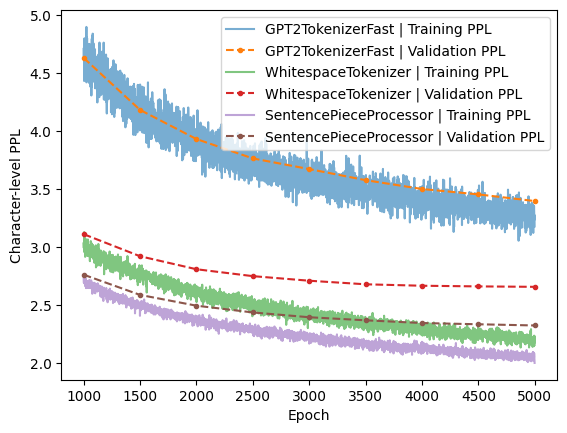

In [30]:
train_tot_chars = len(text_train)
valid_tot_chars = len(text_valid)

for name, tokenizer in zip(
    ("GPT2TokenizerFast", "WhitespaceTokenizer", "SentencePieceProcessor"),
    (hf_tokenizer, sp_tokenizer, whitespace_tokenizer),
):
    loss_hist = torch.load(f"checkpoints/{name}/chk_4999.pt")["loss"]

    train_loss_epochs = sorted(loss_hist["train"].keys())
    train_loss_values = np.array([loss_hist["train"][e] for e in train_loss_epochs])

    valid_loss_epochs = sorted(loss_hist["valid"].keys())
    valid_loss_values = np.array([loss_hist["valid"][e] for e in valid_loss_epochs])

    train_tot_tokens = len(tokenizer.encode(text_train))  # type: ignore
    valid_tot_tokens = len(tokenizer.encode(text_valid))  # type: ignore

    train_ppl_values = np.exp(train_loss_values * train_tot_tokens / train_tot_chars)
    valid_ppl_values = np.exp(valid_loss_values * valid_tot_tokens / valid_tot_chars)

    print(f"{name:>25s} Final Character-level PPL (Valid. set) {valid_ppl_values[-1]:.2f}")

    plt.plot(train_loss_epochs[1000:], train_ppl_values[1000:], label=f"{name} | Training PPL", alpha=0.6)
    plt.plot(valid_loss_epochs[2:], valid_ppl_values[2:], label=f"{name} | Validation PPL", marker=".", ls="--")

plt.xlabel("Epoch")
plt.ylabel("Character-level PPL")
plt.legend()
pass

The perplexity metrics reveal a clear and consistent hierarchy in model
performance across both word and character levels. SentencePiece is the clear
winner. By training on the target corpus, it developed a vocabulary that is
highly optimized for Polish. It achieves the lowest (best) perplexity on both
metrics. Whitespace tokenizer performs in the middle. While its vocabulary
consists of full, in-domain Polish words, its performance is significantly
handicapped by the OOV (Out-Of-Vocabulary) problem. The poor performance of
GPT-2 is a strong indicator of a severe vocabulary mismatch. The model, trained
primarily on English web text, is failing to tokenize Polish text effectively.
This is confirmed by its high validation loss in the plot and will be even more
evident in the qualitative analysis.

### OOV (Out-Of-Vocabulary) statistics

The 11.52% OOV fraction for the Whitespace tokenizer is a critical flaw. This
means that over 1 in 10 words in the validation set are completely unknown to
the model, being replaced by the generic `<UNK>` token. This significant
information loss directly contributes to its higher perplexity compared to
SentencePiece.

In [13]:
tokens = whitespace_tokenizer.encode(text_valid)
oov_frac = sum(1 for tok in tokens if tok == 0) / len(tokens)
print(f"OOV Fraction (Whitespace Tokenizer): {oov_frac:.2%}")

OOV Fraction (Whitespace Tokenizer): 11.52%


### Efficiency metrics

#### Tokenization throughput

The Whitespace tokenizer is the fastest (2.95M toks/s) because its logic is the
simplest (a regex findall and a dictionary lookup). SentencePiece is slightly
slower (2.58M toks/s) due to its more complex Unigram segmentation algorithm.
GPT-2 is by far the slowest (1.11M toks/s). This is likely due to its complex
byte-pair merging logic.

In [16]:
import time

for tokenizer in (hf_tokenizer, whitespace_tokenizer, sp_tokenizer):
    t = time.perf_counter()
    tokens = tokenizer.encode(text_valid)  # type: ignore
    t = time.perf_counter() - t
    print(f"{type(tokenizer).__name__:>25s} throughput: {len(tokens)/t/1e6:.2f}M toks/s")

        GPT2TokenizerFast throughput: 1.11M toks/s
      WhitespaceTokenizer throughput: 2.95M toks/s
   SentencePieceProcessor throughput: 2.58M toks/s


#### Average tokens per word

GPT-2 is extremely inefficient at 3.02 tokens per word. This inflates the
sequence length, dramatically increasing the computational cost (memory and
time) of training and inference. SentencePiece is highly efficient at 1.27
tokens per word, indicating it captures most common words as single tokens and
only splits rarer words into a small, manageable number of subwords. Whitespace
is 1.00 by definition, as it does not split words.

In [18]:
valid_tot_words = len(whitespace_tokenizer.encode(text_valid))

for tokenizer in (hf_tokenizer, whitespace_tokenizer, sp_tokenizer):
    valid_tot_tokens = len(tokenizer.encode(text_valid))
    print(f"{type(tokenizer).__name__:>25s} avg. tokens per word: {valid_tot_tokens/valid_tot_words:.2f}")

        GPT2TokenizerFast avg. tokens per word: 3.02
      WhitespaceTokenizer avg. tokens per word: 1.00
   SentencePieceProcessor avg. tokens per word: 1.27


## Qualitative Analysis

In [26]:
text1 = """Fotosynteza to fundamentalny proces biochemiczny, podczas którego
        organizmy autotroficzne, głównie rośliny i algi, przekształcają energię
        świetlną, wodę oraz dwutlenek węgla w związki organiczne, uwalniając
        tlen jako produkt uboczny."""

text2 = """Wynalezienie druku przez Johannesa Gutenberga około 1450 roku, z
        wykorzystaniem ruchomych czcionek, zrewolucjonizowało Europę,
        umożliwiając masową produkcję książek oraz szybkie rozpowszechnianie się
        wiedzy i idei w epoce renesansu."""

text3 = """Tektonika płyt to teoria naukowa opisująca wielkoskalowe ruchy płyt
        litosfery Ziemi, które, zderzając się i rozsuwając, są odpowiedzialne za
        formowanie kontynentów, gór oraz za zjawiska sejsmiczne i
        wulkaniczne."""

In [42]:
from textwrap import wrap

for tokenizer in (hf_tokenizer, whitespace_tokenizer, sp_tokenizer):
    print(type(tokenizer).__name__)
    print("-" * 80)
    for text in [text1, text2, text3]:
        print("\n".join(wrap("|".join(tokenizer.decode([tok]) for tok in tokenizer.encode(text)))))  # type: ignore
        print()

GPT2TokenizerFast
--------------------------------------------------------------------------------
F|otos|ynt|e|za| to| fundamental|ny| pro|ces| bi|ochem|icz|ny|,|
pod|cz|as| k|t|ó|re|go| | | | | | | | | organ|iz|my|
aut|ot|ro|f|icz|ne|,| g|ł|ó|wn|ie| ro|�|�|lin|y| i| al|gi|,|
pr|z|eks|z|ta|ł|c|aj|�|�| ener|gi|�|�| | | | | | | | |
�|�|w|iet|ln|�|�|,| w|od|�|�| or|az| dw|ut|len|ek| w|�|�|gl|a| w|
z|wi|�|�|z|ki| organic|z|ne|,| u|wal|nia|j|�|�|c| | | | | | | | |
t|len| j|ako| produ|kt| ub|oc|z|ny|.

W|yn|alez|ien|ie| dru|ku| pr|ze|z| Johannes|a| Gutenberg|a| o|ko|ł|o|
14|50| ro|ku|,| z| | | | | | | | | w|yk|or|zy|st|ani|em| r|uch|omy|ch|
cz|c|ion|ek|,| z|rew|ol|uc|jon|iz|owa|ł|o| Euro|p|�|�|,| | | | | | | |
| u|mo|�|�|li|w|ia|j|�|�|c| mas|ow|�|�| produ|k|c|j|�|�|
k|si|�|�|�|�|ek| or|az| s|zy|b|kie| ro|z|p|ows|ze|chn|ian|ie| si|�|�|
| | | | | | | | w|ied|zy| i| ide|i| w| ep|o|ce| re|nes|ans|u|.

T|ek|ton|ika| p|ł|yt| to| te|oria| n|au|k|owa| op|is|uj|�|�|ca|
w|iel|kos|k|al|owe| r|uch|y| p

The sample texts make the reason for the quantitative results immediately
obvious. GPT-2 tokenizer is breaking Polish diacritics into fallback bytes
(which is difficult to visualize cleanly thus the "�" symbols). This is because
characters like `ś`, `ą`, and `ł` are not in its English-trained vocabulary and
are multi-byte in UTF-8. The model is forced to learn Polish at a messy,
sub-character byte level, which is incredibly inefficient and explains both its
high token-per-word ratio and its terrible perplexity.

Whitespace tokenizer works perfectly for common words but fails on any word that
is slightly complex (e.g. "autotroficzny") and probably wasn't in the top ~50k.
This confirms the 11.52% OOV rate is a major issue.

SentencePiece tokenizer is the clear winner. It correctly handles all Polish
characters, keeps common words whole and intelligently splits rarer or complex
words into meaningful subwords (e.g. "Fotosynte|za", "auto|trof|iczne",
"z|rewolucjonizował|o"). This provides the model with a clean, efficient, and
open-vocabulary representation, which directly led to its superior performance.

## Analysis

This experiment clearly demonstrates the critical impact of tokenization
strategy on model performance, especially when dealing with a language that is
not the tokenizer's "native tongue".

* The SentencePiece tokenizer, trained from scratch on the 49MB Polish corpus,
vastly outperformed all other models. It achieved the lowest word-level PPL
(156.87) and character-level PPL (2.33) and had an excellent token-per-word
ratio (1.27). This shows that even a small, domain-specific vocabulary is
superior to a large, general-purpose one if the domain (language) is different.

* The GPT-2 tokenizer was a complete failure on this task. Its vocabulary, built
for English text, could not handle Polish characters. It defaulted to byte-level
encoding, resulting in an explosion of the token-per-word ratio (3.02) and huge
word-level PPL (1516.77).

* The Whitespace tokenizer was a simple and fast baseline, but its performance was
fundamentally capped by its OOV problem.